In [3]:
%pip install tqdm
!python -m spacy download en_core_web_sm
%pip install --no-build-isolation --force-reinstall \
  "numpy==2.3.3" "pandas==2.3.1" "scipy==1.14.1" "matplotlib==3.9.2" \
  "bottleneck>=1.4.0" "numexpr>=2.10.0" tqdm
%pip install "spacy==3.7.6"
import sys, subprocess
subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)

Note: you may need to restart the kernel to use updated packages.
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
  Obtaining dependency information for numpy==2.3.3 from https://files.pythonhosted.org/packages/93/fb/9af1082bec870188c42a1c239839915b74a5099c392389ff04215dcee812/numpy-2.3.3-cp311-cp311-macosx_14_0_arm64.whl.metadata
  Using cached numpy-2.3.3-cp311-cp311-macosx_14_0_arm64.whl.metadata (62 kB)
  Obtaining dependency information for pandas==2.3.1 from https://files.pythonhosted.org/packages/ec/d3/3c37cb724d76a841f14b8f5fe57e5e3645207cc67370e4f84717e8bb7657/pandas-2.3.1-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Using cached pandas-2.3.1-cp311-cp311-macosx_11_0_arm64.whl.metadata (91 kB)
  Obtaining dependency information for scipy==1.14.1 from https://files.pythonhosted.org/pac

CompletedProcess(args=['/Users/mathieu/anaconda3/bin/python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

In [4]:
import pandas as pd
import os
import re
import numpy as np
from collections import defaultdict, Counter
from tqdm import tqdm
import ast
from utils_challenge1 import extraire_contexte_mot, match_tableaux, reconstruire_embeddings, retour_dataset_HVD, extraire_contexte_mot_df_HVD
import pickle
import spacy
import matplotlib.pyplot as plt

from pathlib import Path
import json
import pyarrow

nlp = spacy.load("en_core_web_sm")
stop_words_spacy = nlp.Defaults.stop_words

In [5]:
matrice_A = np.fromfile("donnees/6B.300d.bin", dtype=np.float32).reshape(300, 300)

In [6]:
glove = {}
with open("donnees/glove.6B.300d.txt", "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        vector = np.array(parts[1:], dtype=np.float32)
        glove[word] = vector

### si le dataset du Congrès est chargé on peut calculer les datasets sur lesquels on va travailler, mais comme il est trop lourd (4go) pour être importé sur Git, on peut se contenter de charger les datasets de travail du dossier donnees

In [ ]:
#df_imm=extraire_contexte_mot("immigration",rayon=5,supprimer_stopwords=True)
#df_imm=match_tableaux(df_imm)
#df_fed=extraire_contexte_mot("federal_reserve",rayon=5, multi_mot = True, supprimer_stopwords=True)
#df_fed=match_tableaux(df_fed)
#df_mon=extraire_contexte_mot("monetary_policy",rayon=5, multi_mot = True, supprimer_stopwords=True)
#df_mon=match_tableaux(df_mon)

In [8]:
df_imm=pd.read_csv("donnees/immigration5stopEXCLU.csv")
df_imm=reconstruire_embeddings(df_imm, glove, matrice_A)

In [9]:
df_fed=pd.read_csv("donnees/federal_reserve5stopEXCLU.csv")
df_fed=reconstruire_embeddings(df_fed,glove,matrice_A)

In [10]:
df_mon=pd.read_csv("donnees/monetary_policy5stopEXCLU.csv")
df_mon=reconstruire_embeddings(df_mon,glove,matrice_A)

# Deuxième Dataset plus propre - DATASET HARVARD

### même principe pour le dataset de Harvard

In [ ]:
#df=retour_dataset_HVD("datasetHarvard")
#df_HVD_imm=extraire_contexte_mot_HVD(df,"immigration",rayon=5,supprimer_stopwords=True)
#df_HVD_imm=match_tableaux(df_HVD_imm)
#df_HVD_fed=extraire_contexte_mot_HVD(df,"federal_reserve",rayon=5, multi_mot = True, supprimer_stopwords=True)
#df_HVD_fed=match_tableaux(df_HVD_fed)
#df_HVD_mon=extraire_contexte_mot_HVD(df,"monetary_policy",rayon=5, multi_mot = True, supprimer_stopwords=True)
#df_HVD_mon=match_tableaux(df_HVD_mon)

In [11]:
df_HVD_imm=pd.read_csv("donnees/HVDimmigration5stopEXCLU.csv")
df_HVD_imm=reconstruire_embeddings(df_HVD_imm, glove, matrice_A)

In [12]:
df_HVD_fed=pd.read_csv("donnees/HVDfederal_reserve5stopEXCLU.csv")
df_HVD_fed=reconstruire_embeddings(df_HVD_fed,glove,matrice_A)

In [13]:
df_HVD_mon = pd.read_csv('donnees/HVDmonetary_policy5stopEXCLU.csv')
df_HVD_mon=reconstruire_embeddings(df_HVD_mon, glove, matrice_A)

# Regression linéaire multivariée

In [14]:
def fit_embedding_regression(df: pd.DataFrame, embed_col='embedding', party_col='party'):
    """
    OLS multivariée: Y = α·1 + β·1(Républicain) + ε
    - Filtre sur party ∈ {'R','D'}
    - Garde uniquement les lignes avec embeddings bien formés (même dimension)
    - Retourne α (intercept), β (vecteur d'effet R), T_obs = ||β||₂, et les moyennes de groupe
    """
    # 1) Filtre R/D
    dfin = df[df[party_col].isin(['R', 'D'])].copy()
    if dfin.empty:
        raise ValueError("Aucune ligne avec party ∈ {'R','D'} après filtrage.")

    # 2) Assurer une dimension d'embedding cohérente + drop NA
    dfin = dfin[dfin[embed_col].notna()].copy()
    # Convertit en arrays et filtre si longueurs incohérentes
    emb_as_array = []
    dims = None
    keep_idx = []
    for i, emb in enumerate(dfin[embed_col].tolist()):
        # tolère list/np.array
        arr = np.asarray(emb, dtype=float)
        if arr.ndim != 1:
            continue
        if dims is None:
            dims = arr.shape[0]
            if dims == 0:
                raise ValueError("Embeddings vides.")
        if arr.shape[0] != dims or np.any(~np.isfinite(arr)):
            continue
        emb_as_array.append(arr)
        keep_idx.append(True)
    if not emb_as_array:
        raise ValueError("Aucun embedding valide trouvé (dimensions incohérentes ou NaN).")

    dfin = dfin.iloc[np.where(keep_idx)[0]].copy()
    Y = np.vstack(emb_as_array)                     # (n, d)

    # 3) Matrice de design X = [constante, 1(R)]
    R_ind = (dfin[party_col] == 'R').astype(int).to_numpy().reshape(-1, 1)
    X = np.hstack([np.ones((len(dfin), 1)), R_ind])  # (n, 2)

    # 4) OLS multivariée en une passe (lstsq)
    #    B a la forme (2, d) : 1ère ligne = α, 2ème = β
    B, *_ = np.linalg.lstsq(X, Y, rcond=None)
    alpha = B[0, :]                 # embedding moyen pour le groupe de référence (D)
    beta  = B[1, :]                 # déplacement sémantique R vs D
    T_obs = float(np.linalg.norm(beta, ord=2))

    # 5) Moyennes de groupe (utile pour l’interprétation)
    mean_D = alpha
    mean_R = alpha + beta

    # (Optionnel) R^2 multivarié global (variance expliquée moyenne par dimension)
    Yhat = X @ B
    ss_res = np.sum((Y - Yhat) ** 2, axis=0)
    ss_tot = np.sum((Y - Y.mean(axis=0)) ** 2, axis=0)
    R2_per_dim = 1 - ss_res / np.maximum(ss_tot, 1e-12)
    R2_mean = float(np.mean(R2_per_dim))

    return {
        "alpha": alpha,          # np.array (d,)
        "beta": beta,            # np.array (d,)
        "T_obs_norm_beta": T_obs,
        "mean_D": mean_D,        # np.array (d,)
        "mean_R": mean_R,        # np.array (d,)
        "R2_mean": R2_mean,
        "n_used": Y.shape[0],
        "d": Y.shape[1],
    }

In [15]:
# --- Exemple d’usage ---
results_imm = fit_embedding_regression(df_imm, embed_col='embedding', party_col='party')
print("||β||₂ =", results_imm["T_obs_norm_beta"], "| n =", results_imm["n_used"], " | d =", results_imm["d"])

||β||₂ = 0.09904124618935234 | n = 59818  | d = 300


In [16]:
# --- Exemple d’usage ---
results_HVD_imm = fit_embedding_regression(df_HVD_imm, embed_col='embedding', party_col='party')
print("||β||₂ =", results_HVD_imm["T_obs_norm_beta"], "| n =", results_HVD_imm["n_used"], " | d =", results_HVD_imm["d"])

||β||₂ = 0.11050346541527252 | n = 81011  | d = 300


In [17]:
results_fed = fit_embedding_regression(df_fed, embed_col='embedding', party_col='party')
print("||β||₂ =", results_fed["T_obs_norm_beta"], "| n =", results_fed["n_used"], " | d =", results_fed["d"])

||β||₂ = 0.055538129988807756 | n = 17725  | d = 300


In [18]:
results_HVD_fed = fit_embedding_regression(df_HVD_fed, embed_col='embedding', party_col='party')
print("||β||₂ =", results_HVD_fed["T_obs_norm_beta"], "| n =", results_HVD_fed["n_used"], " | d =", results_HVD_fed["d"])

||β||₂ = 0.06590471969834132 | n = 16147  | d = 300


In [19]:
results_mon = fit_embedding_regression(df_mon, embed_col='embedding', party_col='party')
print("||β||₂ =", results_mon["T_obs_norm_beta"], "| n =", results_mon["n_used"], " | d =", results_mon["d"])

||β||₂ = 0.06485417425354023 | n = 3829  | d = 300


In [20]:
results_HVD_mon = fit_embedding_regression(df_HVD_mon, embed_col='embedding', party_col='party')
print("||β||₂ =", results_HVD_mon["T_obs_norm_beta"], "| n =", results_HVD_mon["n_used"], " | d =", results_HVD_mon["d"])

||β||₂ = 0.07848081178306744 | n = 2383  | d = 300


# Test par permutation

In [21]:
# --- 1) Utilitaire: parser les embeddings proprement (comme dans ta fonction) ---
def _parse_embeddings(df, embed_col='embedding', party_col='party'):
    dfin = df[df[party_col].isin(['R','D'])].copy()
    if dfin.empty:
        raise ValueError("Aucune ligne avec party ∈ {'R','D'} après filtrage.")
    dfin = dfin[dfin[embed_col].notna()].copy()

    emb_arrs = []
    keep_mask = []
    dims = None
    for emb in dfin[embed_col].tolist():
        arr = np.asarray(emb, dtype=float)
        if arr.ndim != 1:
            keep_mask.append(False); continue
        if dims is None:
            dims = arr.shape[0]
            if dims == 0:
                raise ValueError("Embeddings vides.")
        if arr.shape[0] != dims or np.any(~np.isfinite(arr)):
            keep_mask.append(False); continue
        emb_arrs.append(arr)
        keep_mask.append(True)

    if not emb_arrs:
        raise ValueError("Aucun embedding valide (dimensions incohérentes ou NaN).")

    keep_mask = np.array(keep_mask, dtype=bool)
    dfin = dfin.loc[keep_mask].reset_index(drop=True)   # <<<<<< important
    Y = np.vstack(emb_arrs)                              # (n, d)
    R = (dfin[party_col] == 'R').astype(int).to_numpy()  # (n,)
    return dfin, Y, R

# --- 2) Norme de beta sans refitter l’OLS: beta = mean(Y|R=1) - mean(Y|R=0) ---
def _beta_and_T_from_R(Y, R):
    # sécurité : 2 groupes non vides
    if R.sum() == 0 or R.sum() == len(R):
        return None, np.nan
    mean_R = Y[R == 1].mean(axis=0)
    mean_D = Y[R == 0].mean(axis=0)
    beta = mean_R - mean_D
    T = float(np.linalg.norm(beta, ord=2))
    return beta, T

# --- 3) Générateur de permutations (par lignes, par grappe, et/ou stratifiées) ---
def _permute_R(dfin, R, group_col=None, strata_cols=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    R_perm = np.empty_like(R)

    if strata_cols is None or len(strata_cols) == 0:
        strata_key = pd.Series(0, index=dfin.index)
    else:
        strata_key = dfin[strata_cols].astype(str).agg('||'.join, axis=1)

    if group_col is None:
        # permutation simple au niveau des lignes, par strate
        for _, idx in strata_key.groupby(strata_key).groups.items():
            idx = np.fromiter(idx, dtype=int)        # idx est déjà 0..n-1
            R_perm[idx] = rng.permutation(R[idx])
    else:
        # permutation au niveau des groupes, par strate
        groups = dfin[group_col].to_numpy()
        for _, idx in strata_key.groupby(strata_key).groups.items():
            idx = np.fromiter(idx, dtype=int)
            g_s = groups[idx]
            df_s = pd.DataFrame({'g': g_s, 'R': R[idx]})
            lab_by_g = df_s.groupby('g')['R'].mean().round().astype(int)
            permuted_labels = lab_by_g.sample(
                frac=1.0,
                random_state=int(rng.integers(0, 2**32-1))
            )
            map_lab = permuted_labels.to_dict()
            R_perm[idx] = [map_lab[gg] for gg in g_s]

    return R_perm

# --- 4) Test par permutation ---
def permutation_pvalue_for_df(df, embed_col='embedding', party_col='party',
                              B=1000, random_state=0, group_col=None, strata_cols=None):
    """
    Calcule T_obs = ||beta||_2 et la p-value (>=) par permutation des étiquettes de parti.
    - group_col: ex. 'speakerid' pour permuter par grappe
    - strata_cols: ex. ['chamber','year'] pour permuter à l'intérieur des strates
    """
    rng = np.random.default_rng(random_state)

    dfin, Y, R = _parse_embeddings(df, embed_col=embed_col, party_col=party_col)

    # T observé
    beta_obs, T_obs = _beta_and_T_from_R(Y, R)
    if np.isnan(T_obs):
        raise ValueError("Impossible de calculer T_obs: un des groupes est vide.")

    # Boucle de permutations
    count_ge = 0
    T_perm = np.empty(B, dtype=float)
    for b in range(B):
        Rb = _permute_R(dfin, R, group_col=group_col, strata_cols=strata_cols, rng=rng)
        _, Tb = _beta_and_T_from_R(Y, Rb)
        T_perm[b] = Tb
        if Tb >= T_obs:
            count_ge += 1

    pval = (1 + count_ge) / (B + 1)
    return {
        'T_obs': T_obs,
        'p_value': pval,
        'T_perm': T_perm,     # utile si tu veux tracer la distribution
        'n_used': Y.shape[0],
        'd': Y.shape[1],
        'B': B
    }

In [22]:
# --- Exemple d'usage minimal (sans cluster ni strates) ---
res_imm = permutation_pvalue_for_df(df_imm, embed_col='embedding', party_col='party', B=2000, random_state=42)
print("T_obs =", res_imm['T_obs'], " | p-value =", res_imm['p_value'])

T_obs = 0.0990412461893072  | p-value = 0.0004997501249375312


In [23]:
res_fed = permutation_pvalue_for_df(df_fed, embed_col='embedding', party_col='party', B=2000, random_state=42)
print("T_obs =", res_fed['T_obs'], " | p-value =", res_fed['p_value'])

T_obs = 0.055538129988804454  | p-value = 0.0004997501249375312


In [24]:
res_mon = permutation_pvalue_for_df(df_mon, embed_col='embedding', party_col='party', B=2000, random_state=42)
print("T_obs =", res_mon['T_obs'], " | p-value =", res_mon['p_value'])

T_obs = 0.06485417425353905  | p-value = 0.0004997501249375312


# Evolution de la norme de Beta

In [25]:
def fit_embedding_regression_by_year(
    df: pd.DataFrame,
    embed_col: str = 'embedding',
    party_col: str = 'party',
    date_col: str = 'date'
) -> pd.DataFrame:
    """
    Calcule, pour chaque année, la norme de β issue de la régression
    Y = α + β·1(R) + ε
    où Y est l'embedding contextuel (vectoriel).

    Sortie : DataFrame avec colonnes :
        - 'year'       : année (int)
        - 'beta_norm'  : ||β||₂ (float) pour l'année
        - 'n_R'        : nombre d'occurrences républicaines
        - 'n_D'        : nombre d'occurrences démocrates
    """
    # 1) Filtre R/D + embeddings non nuls
    dfin = df[df[party_col].isin(['R', 'D'])].copy()
    dfin = dfin[dfin[embed_col].notna()].copy()
    if dfin.empty:
        return pd.DataFrame(columns=['year', 'beta_norm', 'n_R', 'n_D'])

    # 2) Assure un champ 'year'
    if not np.issubdtype(dfin[date_col].dtype, np.datetime64):
        dfin[date_col] = pd.to_datetime(dfin[date_col], errors='coerce')
    dfin = dfin.dropna(subset=[date_col]).copy()
    if dfin.empty:
        return pd.DataFrame(columns=['year', 'beta_norm', 'n_R', 'n_D'])
    dfin['year'] = dfin[date_col].dt.year

    # 3) Convertit les embeddings en arrays et vérifie dimension
    d = None
    keep_idx = []
    for emb in dfin[embed_col].tolist():
        arr = np.asarray(emb, dtype=float)
        if arr.ndim != 1 or np.any(~np.isfinite(arr)):
            keep_idx.append(False)
            continue
        if d is None:
            d = arr.shape[0]
            if d == 0:
                keep_idx.append(False)
                continue
        if arr.shape[0] != d:
            keep_idx.append(False)
            continue
        keep_idx.append(True)

    dfin = dfin.iloc[np.where(keep_idx)[0]].copy()
    if dfin.empty:
        return pd.DataFrame(columns=['year', 'beta_norm', 'n_R', 'n_D'])

    # 4) Regroupe par année et calcule ||β||₂ + nb occurrences
    rows = []
    for yr, g in dfin.groupby('year', sort=True):
        g_R = g[g[party_col] == 'R'][embed_col].tolist()
        g_D = g[g[party_col] == 'D'][embed_col].tolist()
        n_R, n_D = len(g_R), len(g_D)
        if n_R == 0 or n_D == 0:
            continue

        mean_R = np.mean(np.vstack([np.asarray(x, dtype=float) for x in g_R]), axis=0)
        mean_D = np.mean(np.vstack([np.asarray(x, dtype=float) for x in g_D]), axis=0)
        beta = mean_R - mean_D
        beta_norm = float(np.linalg.norm(beta))

        rows.append((int(yr), beta_norm, n_R, n_D))

    out = pd.DataFrame(rows, columns=['year', 'beta_norm', 'n_R', 'n_D']).sort_values('year').reset_index(drop=True)
    return out

def plot_beta_evolution(df_beta_year, mot):
    """
    Trace l'évolution de ||β||₂ au fil du temps pour un mot donné.
    """
    plt.figure(figsize=(10,5))
    plt.plot(df_beta_year['year'], df_beta_year['beta_norm'], marker='o', linestyle='-')
    
    plt.title(f"Évolution temporelle de ||β||₂ pour {mot}")
    plt.xlabel("Année")
    plt.ylabel("Norme de β (||β||₂)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

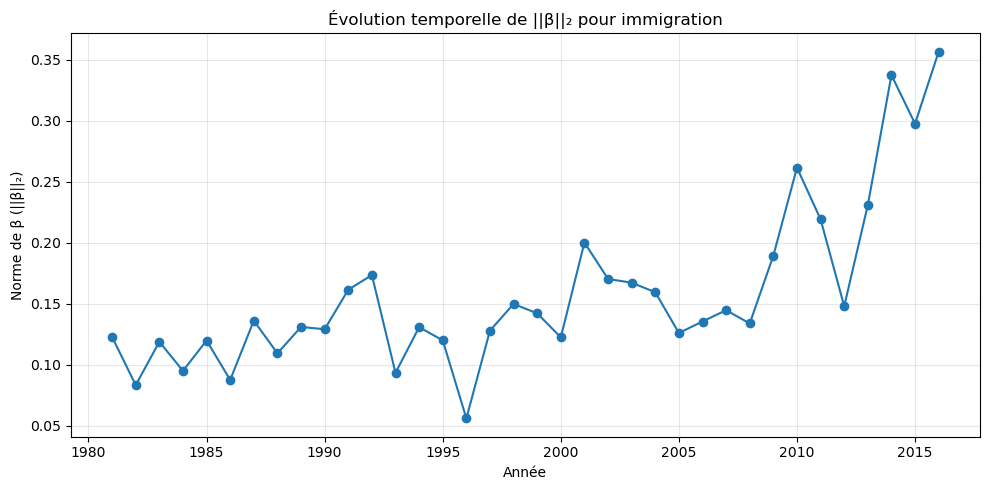

In [26]:
df_beta_imm = fit_embedding_regression_by_year(df_imm)
plot_beta_evolution(df_beta_imm, "immigration")

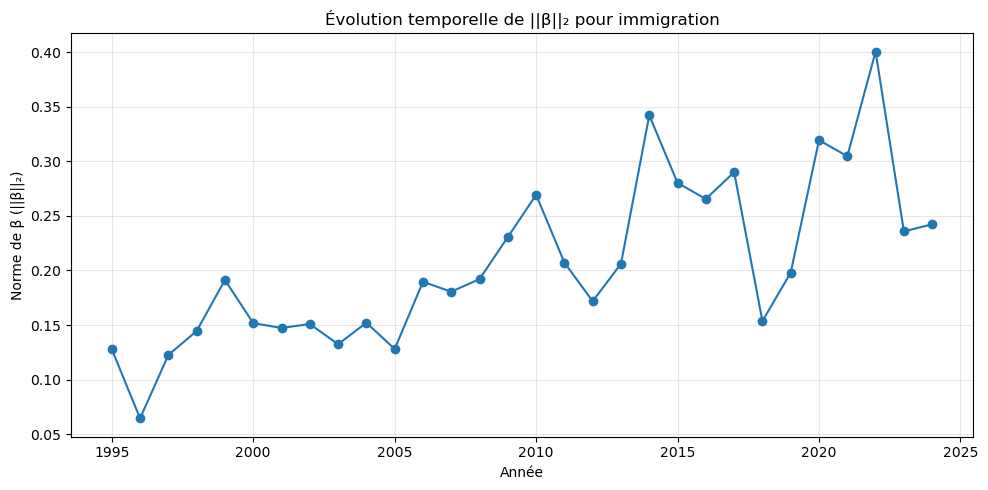

In [27]:
df_beta_HVD_imm = fit_embedding_regression_by_year(df_HVD_imm)
plot_beta_evolution(df_beta_HVD_imm, "immigration")

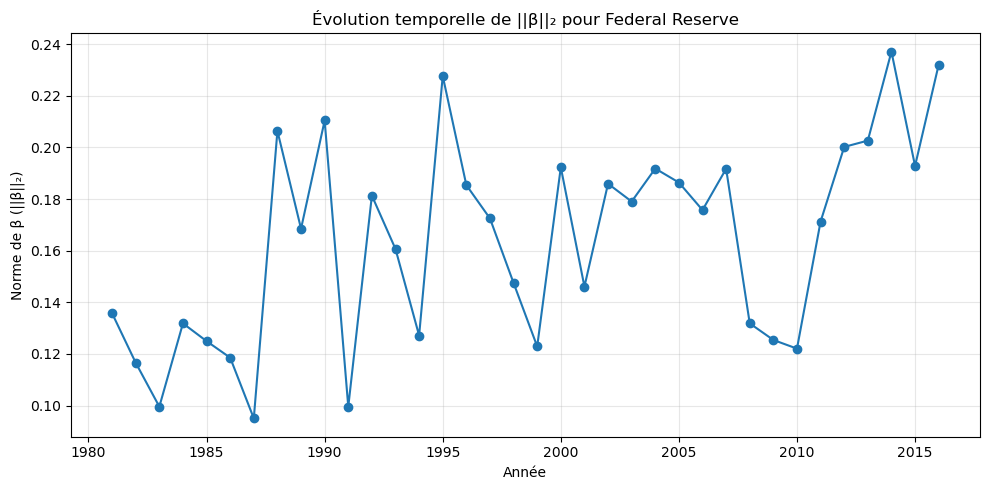

In [28]:
df_beta_fed = fit_embedding_regression_by_year(df_fed)
plot_beta_evolution(df_beta_fed, "Federal Reserve")

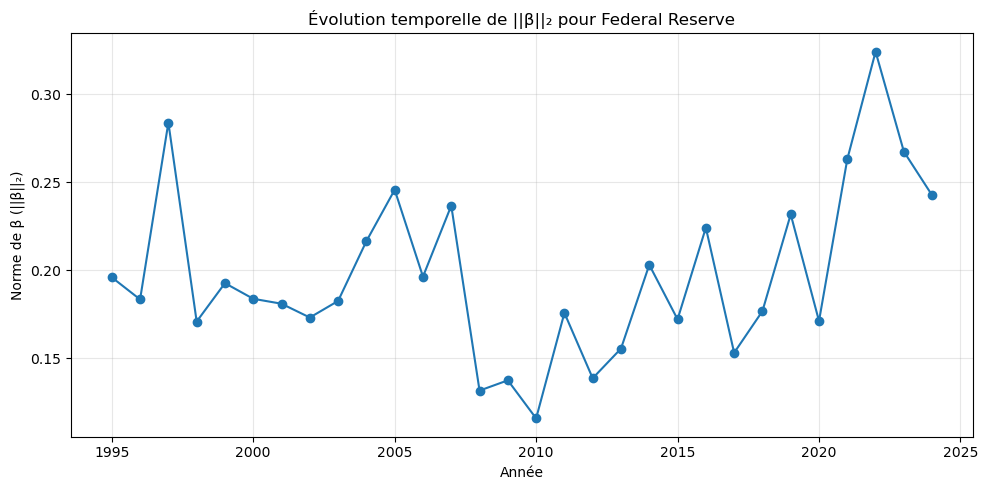

In [29]:
df_beta_HVD_fed = fit_embedding_regression_by_year(df_HVD_fed)
plot_beta_evolution(df_beta_HVD_fed, "Federal Reserve")

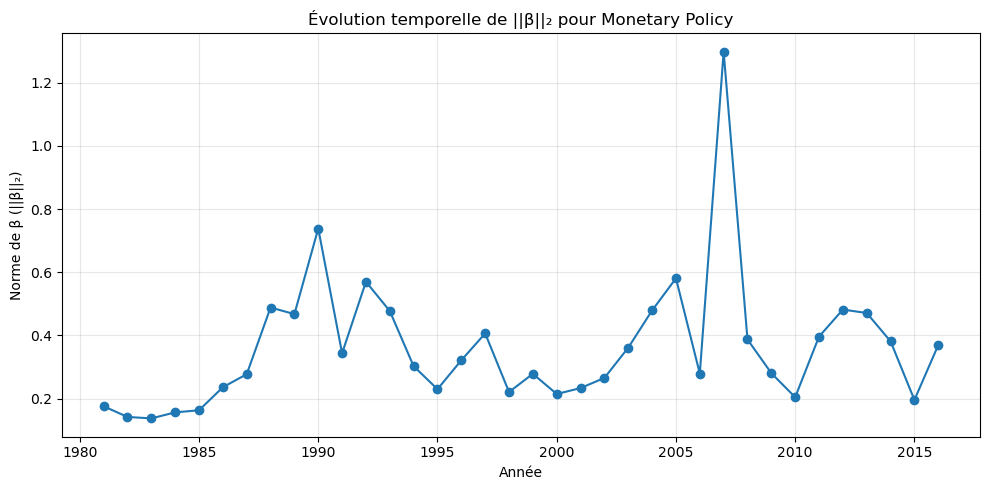

In [30]:
df_beta_mon = fit_embedding_regression_by_year(df_mon)
plot_beta_evolution(df_beta_mon, "Monetary Policy")

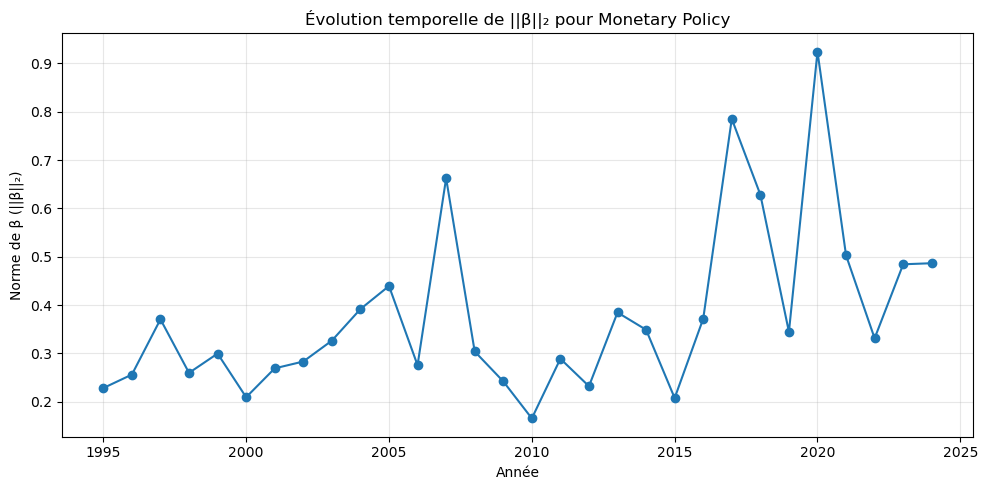

In [31]:
df_beta_HVD_mon = fit_embedding_regression_by_year(df_HVD_mon)
plot_beta_evolution(df_beta_HVD_mon, "Monetary Policy")

# Corrélation avec indices boursiers

In [34]:
%pip install yfinance
import yfinance as yf

# Télécharger données S&P 500
sp500 = yf.download("^GSPC", start="1995-01-01", end="2025-01-01")
sp500["year"] = sp500.index.year
sp500.columns = [col[0] if isinstance(col, tuple) else col for col in sp500.columns]

# Rendement annuel basé sur le dernier cours de l'année
annual_close = sp500.groupby("year")["Close"].last()
sp500_return = annual_close.pct_change()

# Volatilité annuelle (écart-type des rendements quotidiens)
daily_ret = sp500["Close"].pct_change()
sp500_vol = daily_ret.groupby(sp500["year"]).std()

# --- Volumes ---
annual_vol_mean = sp500.groupby("year")["Volume"].mean()
annual_vol_sum  = sp500.groupby("year")["Volume"].sum()
# croissance du volume (différence du log ~ variation en %)
sp500_volume_growth = np.log(annual_vol_mean).diff()

# Construire un DataFrame avec S&P 500 agrégé
df_sp500 = pd.DataFrame({
    "sp500_close": annual_close,
    "sp500_return": sp500_return,
    "sp500_volatility": sp500_vol,
    "sp500_volume_mean": annual_vol_mean,
    "sp500_volume_sum": annual_vol_sum,
    "sp500_volume_growth": sp500_volume_growth,
}).reset_index()

# Fusionner avec tes DataFrames de polarisation
df_all = df_sp500.merge(
    df_beta_HVD_imm[["year", "beta_norm"]].rename(columns={"beta_norm": "beta_immigration"}),
    on="year", how="left"
).merge(
    df_beta_HVD_fed[["year", "beta_norm"]].rename(columns={"beta_norm": "beta_fed"}),
    on="year", how="left"
).merge(
    df_beta_HVD_mon[["year", "beta_norm"]].rename(columns={"beta_norm": "beta_monetary"}),
    on="year", how="left"
)

  Obtaining dependency information for yfinance from https://files.pythonhosted.org/packages/16/bf/7c0c89ff8ba53592b9cb5157f70e90d8bbb04d60094fc4f10035e158b981/yfinance-0.2.66-py2.py3-none-any.whl.metadata
  Preparing metadata (setup.py) ... done
  Obtaining dependency information for frozendict>=2.3.4 from https://files.pythonhosted.org/packages/04/13/d9839089b900fa7b479cce495d62110cddc4bd5630a04d8469916c0e79c5/frozendict-2.4.6-py311-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 949.2/949.2 kB 7.6 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Obtaining dependency information for curl_cffi>=0.7 from https://files.pythonhosted.org/packages/2c/1c/cdb4fb2d16a0e9de068e0e5bc02094e105ce58a687ff30b4c6f88e25a057/curl_cffi-0.13.0-cp39-abi3-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for websockets>=13.0 from https://files.pythonhosted.or

/var/folders/np/t7mtwzx10yd29dp96svr_wkm0000gn/T/ipykernel_15668/651902383.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500 = yf.download("^GSPC", start="1995-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [35]:
df_all

,year,sp500_close,sp500_return,sp500_volatility,sp500_volume_mean,sp500_volume_sum,sp500_volume_growth,beta_immigration,beta_fed,beta_monetary
0,1995,615.929993,NaN,0.004927,3.462038e+08,87243350000,NaN,0.127867,0.195894,0.228106
1,1996,740.739990,0.202637,0.007421,4.114201e+08,104500710000,0.172587,0.064528,0.183317,0.255997
2,1997,970.429993,0.310082,0.011422,5.256481e+08,132988980000,0.245017,0.122661,0.283910,0.370391
3,1998,1229.229980,0.266686,0.012780,6.722617e+08,169409950000,0.246016,0.144543,0.170741,0.259522
4,1999,1469.250000,0.195260,0.011384,8.083420e+08,203702180000,0.184338,0.191337,0.192578,0.299459
5,2000,1320.280029,-0.101392,0.013999,1.034489e+09,260691260000,0.246678,0.151785,0.183688,0.209068
6,2001,1148.079956,-0.130427,0.013579,1.232068e+09,305552780000,0.174786,0.147365,0.180884,0.268890
7,2002,879.820007,-0.233660,0.016397,1.429026e+09,360114650000,0.148300,0.150968,0.173029,0.283033
8,2003,1111.920044,0.263804,0.010752,1.384451e+09,348881650000,-0.031690,0.132446,0.182455,0.326230
9,2004,1211.920044,0.089935,0.006988,1.423204e+09,358647350000,0.027607,0.152166,0.216452,0.391579


lien entre polarisation et rendement ou volatilité du s&p ?

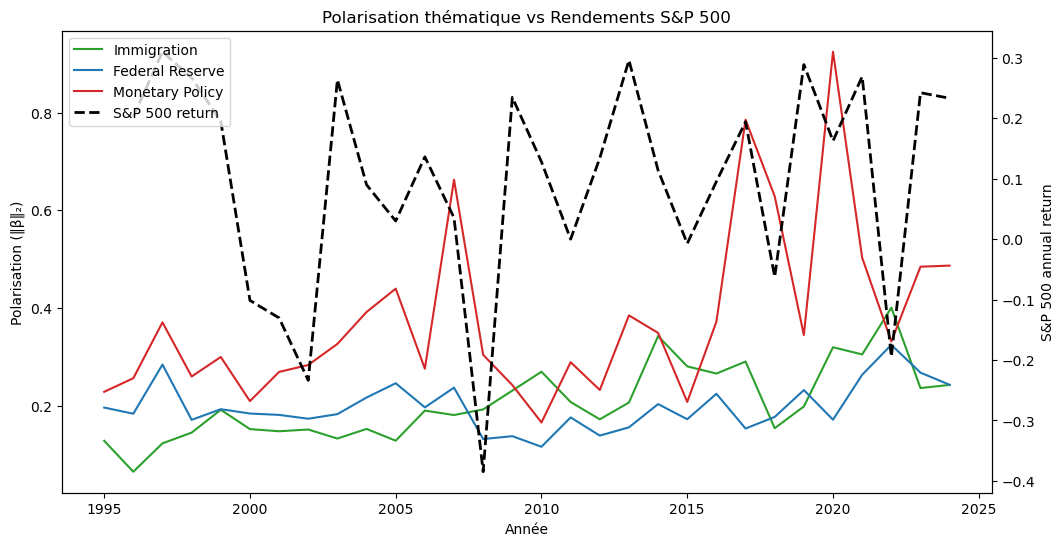

In [36]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Polarisation (traits pleins)
ax1.plot(df_all["year"], df_all["beta_immigration"], label="Immigration", color="tab:green")
ax1.plot(df_all["year"], df_all["beta_fed"], label="Federal Reserve", color="tab:blue")
ax1.plot(df_all["year"], df_all["beta_monetary"], label="Monetary Policy", color="tab:red")

ax1.set_xlabel("Année")
ax1.set_ylabel("Polarisation (‖β‖₂)")

# Axe secondaire : S&P 500 return en pointillé
ax2 = ax1.twinx()
ax2.plot(df_all["year"], df_all["sp500_return"], label="S&P 500 return",
         color="black", linestyle="--", linewidth=2)
ax2.set_ylabel("S&P 500 annual return")

# Récupérer uniquement les handles/labels des deux axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Polarisation thématique vs Rendements S&P 500")
plt.show()

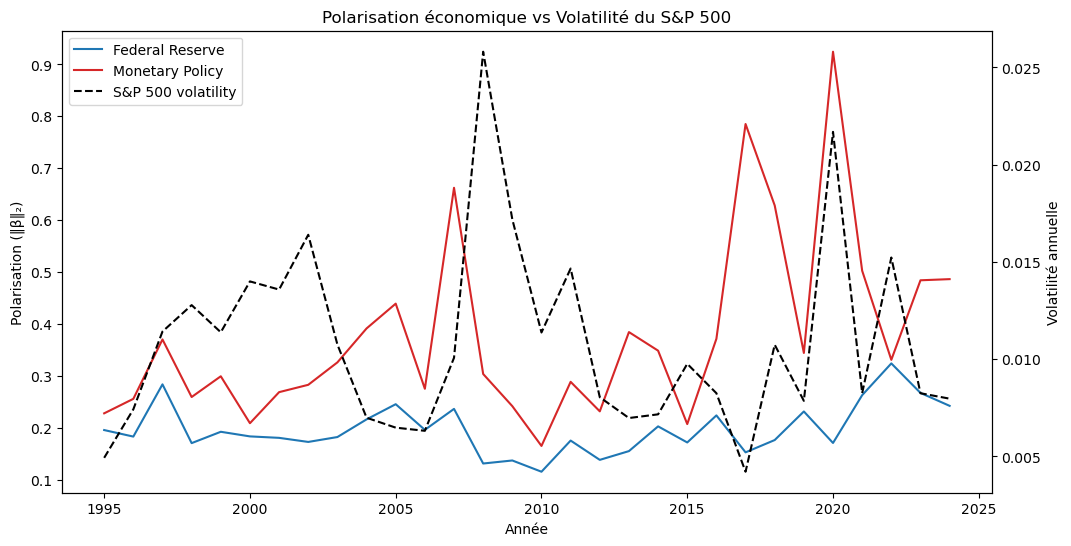

In [37]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Polarisation (traits pleins)
ax1.plot(df_all["year"], df_all["beta_fed"], label="Federal Reserve", color="tab:blue")
ax1.plot(df_all["year"], df_all["beta_monetary"], label="Monetary Policy", color="tab:red")

ax1.set_xlabel("Année")
ax1.set_ylabel("Polarisation (‖β‖₂)")

# Axe secondaire : volatilité S&P 500 (pointillé)
ax2 = ax1.twinx()
ax2.plot(df_all["year"], df_all["sp500_volatility"], label="S&P 500 volatility",
         color="black", linestyle="--")

ax2.set_ylabel("Volatilité annuelle")

# Récupérer les handles/labels des deux axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Polarisation économique vs Volatilité du S&P 500")
plt.show()

In [38]:
# Extraire juste les colonnes utiles
subset = df_all[["beta_fed", "beta_monetary", "sp500_volatility"]]

# Corrélations de Pearson (linéaires)
print("Corrélations de Pearson :")
print(subset.corr(method="pearson"))

# Corrélations de Spearman (rang, robustes aux valeurs extrêmes)
print("\nCorrélations de Spearman :")
print(subset.corr(method="spearman"))


Corrélations de Pearson :
                  beta_fed  beta_monetary  sp500_volatility
beta_fed          1.000000       0.190627         -0.253317
beta_monetary     0.190627       1.000000          0.002003
sp500_volatility -0.253317       0.002003          1.000000

Corrélations de Spearman :
                  beta_fed  beta_monetary  sp500_volatility
beta_fed          1.000000       0.412236         -0.270300
beta_monetary     0.412236       1.000000         -0.199555
sp500_volatility -0.270300      -0.199555          1.000000


In [39]:
from statsmodels.tsa.stattools import grangercausalitytests

# Préparer les données : rendements et polarisation
df_gc_ret = df_all[["sp500_return", "beta_monetary"]].dropna()

print("Granger causality test : Polarisation Monetary Policy -> S&P500 return")
grangercausalitytests(df_gc_ret[["sp500_return", "beta_monetary"]], maxlag=3)

print("\nGranger causality test : S&P500 return -> Polarisation Monetary Policy")
grangercausalitytests(df_gc_ret[["beta_monetary", "sp500_return"]], maxlag=3)

Granger causality test : Polarisation Monetary Policy -> S&P500 return

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.1638  , p=0.6891  , df_denom=25, df_num=1
ssr based chi2 test:   chi2=0.1835  , p=0.6684  , df=1
likelihood ratio test: chi2=0.1829  , p=0.6689  , df=1
parameter F test:         F=0.1638  , p=0.6891  , df_denom=25, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.0825  , p=0.9211  , df_denom=22, df_num=2
ssr based chi2 test:   chi2=0.2024  , p=0.9037  , df=2
likelihood ratio test: chi2=0.2017  , p=0.9041  , df=2
parameter F test:         F=0.0825  , p=0.9211  , df_denom=22, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.3391  , p=0.7973  , df_denom=19, df_num=3
ssr based chi2 test:   chi2=1.3922  , p=0.7074  , df=3
likelihood ratio test: chi2=1.3562  , p=0.7158  , df=3
parameter F test:         F=0.3391  , p=0.7973  , df_denom=19, df_num=3

Granger causality test : S&P

{1: ({'ssr_ftest': (0.9441980747943911, 0.3405088556857716, 25.0, 1),
   'ssr_chi2test': (1.0575018437697181, 0.303785648733485, 1),
   'lrtest': (1.0380210067633016, 0.3082821804287925, 1),
   'params_ftest': (0.9441980747943887, 0.3405088556857716, 25.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (1.0075026155728533, 0.38136422268222525, 22.0, 2),
   'ssr_chi2test': (2.4729609654970033, 0.29040450509232585, 2),
   'lrtest': (2.366182788841158, 0.30633028559955683, 2),
   'params_ftest': (1.0075026155728513, 0.38136422268222575, 22.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.5592106382350298, 0.6483844403773085, 19.0, 3),
   'ssr_chi2test': (2.29570683064907, 0.513343863159579, 3),
   'lrtest': (2.1999523785869997, 0.531957751204774, 3),
   'params_ftest': (0.5592106382350325, 0.6483844403773067, 19.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0., 0., 0., 

In [40]:
from statsmodels.tsa.stattools import grangercausalitytests

# Préparer les données : supprimer les NaN et garder les deux colonnes
df_gc2 = df_all[["beta_monetary", "sp500_volatility"]].dropna()

# Test de Granger : est-ce que volume -> polarisation ?
# maxlag = nombre d'années de retard testées (ex. 3 ans)
print("Granger causality test : Volatilité -> Monetary Policy")
grangercausalitytests(df_gc2[["beta_monetary", "sp500_volatility"]], maxlag=3)

# Inverse : polarisation -> volume
print("\nGranger causality test : Monetary Policy -> Volatilité")
grangercausalitytests(df_gc2[["sp500_volatility", "beta_monetary"]], maxlag=3)


Granger causality test : Volatilité -> Monetary Policy

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=2.9642  , p=0.0970  , df_denom=26, df_num=1
ssr based chi2 test:   chi2=3.3062  , p=0.0690  , df=1
likelihood ratio test: chi2=3.1309  , p=0.0768  , df=1
parameter F test:         F=2.9642  , p=0.0970  , df_denom=26, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=1.9511  , p=0.1649  , df_denom=23, df_num=2
ssr based chi2 test:   chi2=4.7506  , p=0.0930  , df=2
likelihood ratio test: chi2=4.3880  , p=0.1115  , df=2
parameter F test:         F=1.9511  , p=0.1649  , df_denom=23, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.5630  , p=0.0835  , df_denom=20, df_num=3
ssr based chi2 test:   chi2=10.3803 , p=0.0156  , df=3
likelihood ratio test: chi2=8.7833  , p=0.0323  , df=3
parameter F test:         F=2.5630  , p=0.0835  , df_denom=20, df_num=3

Granger causality test : Monetary Policy -> 

{1: ({'ssr_ftest': (0.043000535947014085, 0.8373398685784521, 26.0, 1),
   'ssr_chi2test': (0.047962136248592635, 0.8266480269726595, 1),
   'lrtest': (0.047922518432699235, 0.8267185012294096, 1),
   'params_ftest': (0.04300053594701447, 0.8373398685784521, 26.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (0.4812836075028191, 0.624074815829275, 23.0, 2),
   'ssr_chi2test': (1.1718209573981684, 0.556598859634225, 2),
   'lrtest': (1.1479635285087397, 0.563278126824988, 2),
   'params_ftest': (0.48128360750281574, 0.6240748158292768, 23.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.20117191055099973, 0.8943425726949763, 20.0, 3),
   'ssr_chi2test': (0.8147462377315489, 0.8459367738766925, 3),
   'lrtest': (0.8026952651484294, 0.8488222534588588, 3),
   'params_ftest': (0.20117191055100014, 0.8943425726949757, 20.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0., 0.,

lien entre polarisation et volume ou croissance du volume du s&p ?

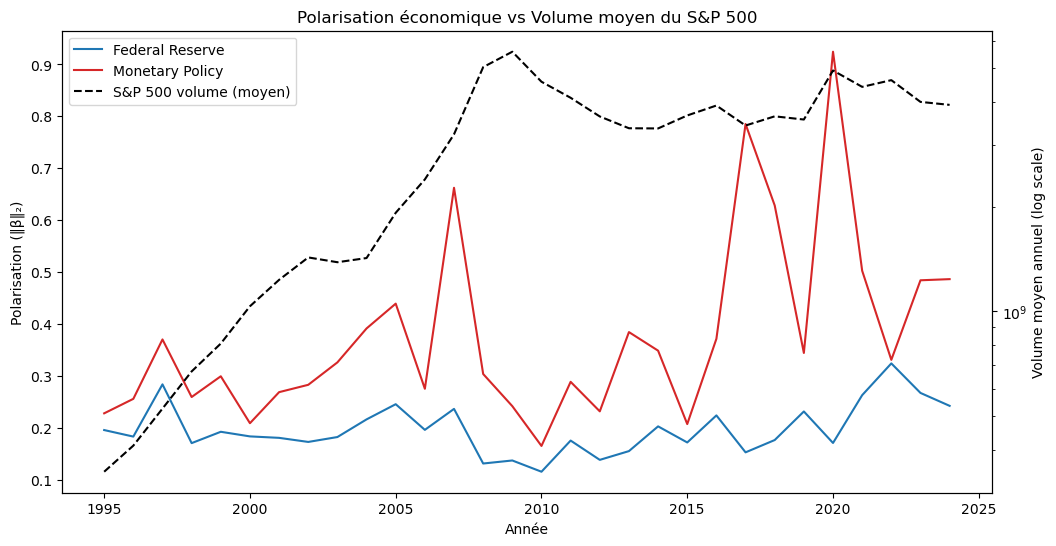

In [41]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12,6))

# Polarisation Fed et Monetary Policy
ax1.plot(df_all["year"], df_all["beta_fed"], label="Federal Reserve", color="tab:blue")
ax1.plot(df_all["year"], df_all["beta_monetary"], label="Monetary Policy", color="tab:red")
ax1.set_xlabel("Année")
ax1.set_ylabel("Polarisation (‖β‖₂)")

# Axe secondaire : volume moyen (échelle log pour lisibilité)
ax2 = ax1.twinx()
ax2.plot(df_all["year"], df_all["sp500_volume_mean"], label="S&P 500 volume (moyen)", 
         color="black", linestyle="--")
ax2.set_ylabel("Volume moyen annuel (log scale)")
ax2.set_yscale("log")

# Légendes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Polarisation économique vs Volume moyen du S&P 500")
plt.show()


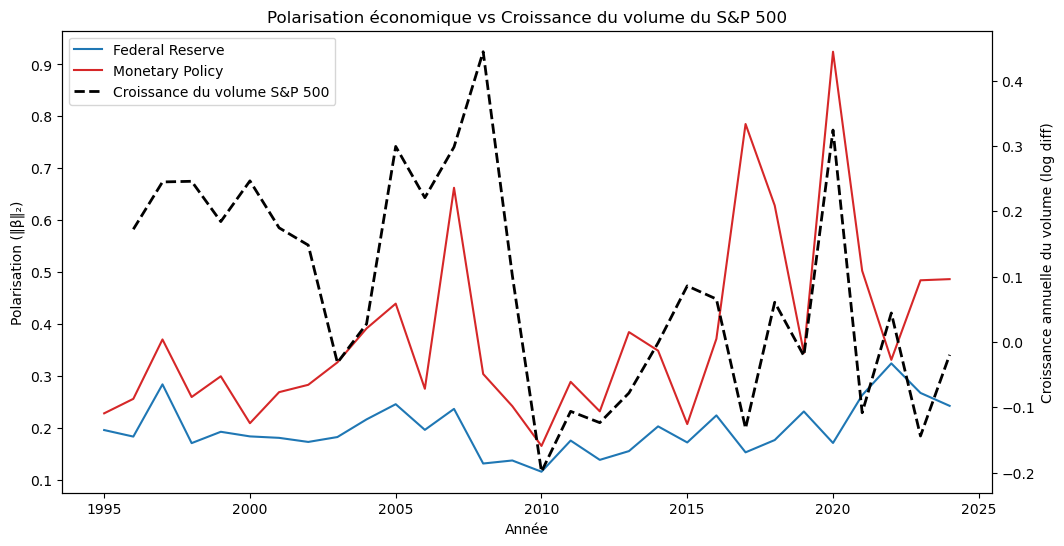

In [42]:
fig, ax1 = plt.subplots(figsize=(12,6))

# Polarisation Fed et Monetary Policy
ax1.plot(df_all["year"], df_all["beta_fed"], label="Federal Reserve", color="tab:blue")
ax1.plot(df_all["year"], df_all["beta_monetary"], label="Monetary Policy", color="tab:red")
ax1.set_xlabel("Année")
ax1.set_ylabel("Polarisation (‖β‖₂)")

# Axe secondaire : croissance du volume en pointillé
ax2 = ax1.twinx()
ax2.plot(df_all["year"], df_all["sp500_volume_growth"], 
         label="Croissance du volume S&P 500", 
         color="black", linestyle="--", linewidth=2)
ax2.set_ylabel("Croissance annuelle du volume (log diff)")

# Légendes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Polarisation économique vs Croissance du volume du S&P 500")
plt.show()

In [43]:
# Extraire juste les colonnes utiles (polarisation + croissance du volume)
subset = df_all[["beta_fed", "beta_monetary", "sp500_volume_growth"]]

# Corrélations de Pearson
print("Corrélations de Pearson :")
print(subset.corr(method="pearson"))

# Corrélations de Spearman
print("\nCorrélations de Spearman :")
print(subset.corr(method="spearman"))

Corrélations de Pearson :
                     beta_fed  beta_monetary  sp500_volume_growth
beta_fed             1.000000       0.190627             0.018302
beta_monetary        0.190627       1.000000             0.055281
sp500_volume_growth  0.018302       0.055281             1.000000

Corrélations de Spearman :
                     beta_fed  beta_monetary  sp500_volume_growth
beta_fed             1.000000       0.412236             0.048276
beta_monetary        0.412236       1.000000            -0.051724
sp500_volume_growth  0.048276      -0.051724             1.000000


In [44]:
from statsmodels.tsa.stattools import grangercausalitytests

# Préparer les données : supprimer les NaN et garder les deux colonnes
df_gc = df_all[["beta_monetary", "sp500_volume_growth"]].dropna()

# Test de Granger : est-ce que volume -> polarisation ?
# maxlag = nombre d'années de retard testées (ex. 3 ans)
print("Granger causality test : Volume -> Monetary Policy")
grangercausalitytests(df_gc[["beta_monetary", "sp500_volume_growth"]], maxlag=3)

# Inverse : polarisation -> volume
print("\nGranger causality test : Monetary Policy -> Volume")
grangercausalitytests(df_gc[["sp500_volume_growth", "beta_monetary"]], maxlag=3)


Granger causality test : Volume -> Monetary Policy

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.5305  , p=0.2275  , df_denom=25, df_num=1
ssr based chi2 test:   chi2=1.7142  , p=0.1904  , df=1
likelihood ratio test: chi2=1.6637  , p=0.1971  , df=1
parameter F test:         F=1.5305  , p=0.2275  , df_denom=25, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.7125  , p=0.5014  , df_denom=22, df_num=2
ssr based chi2 test:   chi2=1.7489  , p=0.4171  , df=2
likelihood ratio test: chi2=1.6946  , p=0.4286  , df=2
parameter F test:         F=0.7125  , p=0.5014  , df_denom=22, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=1.8567  , p=0.1712  , df_denom=19, df_num=3
ssr based chi2 test:   chi2=7.6224  , p=0.0545  , df=3
likelihood ratio test: chi2=6.6845  , p=0.0827  , df=3
parameter F test:         F=1.8567  , p=0.1712  , df_denom=19, df_num=3

Granger causality test : Monetary Policy -> Volu

{1: ({'ssr_ftest': (0.014999405032655334, 0.9035043925800572, 25.0, 1),
   'ssr_chi2test': (0.016799333636573974, 0.8968732161390448, 1),
   'lrtest': (0.016794296051216406, 0.8968885931397957, 1),
   'params_ftest': (0.014999405032650391, 0.9035043925800661, 25.0, 1.0)},
   array([[0., 1., 0.]])]),
 2: ({'ssr_ftest': (0.05235073213161857, 0.9491138176371277, 22.0, 2),
   'ssr_chi2test': (0.12849725159579103, 0.9377718162781784, 2),
   'lrtest': (0.1281924489552182, 0.9379147448320801, 2),
   'params_ftest': (0.05235073213161813, 0.9491138176371277, 22.0, 2.0)},
   array([[0., 0., 1., 0., 0.],
          [0., 0., 0., 1., 0.]])]),
 3: ({'ssr_ftest': (0.13759817726261517, 0.9363169417489532, 19.0, 3),
   'ssr_chi2test': (0.5648767277096833, 0.9044238143738935, 3),
   'lrtest': (0.5588279181741456, 0.905789609114882, 3),
   'params_ftest': (0.13759817726261572, 0.9363169417489532, 19.0, 3.0)},
   array([[0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 1., 0., 0.],
          [0., 0.